# **Section 10: Nested Cross-Validation and Final Model Validation**

This notebook implements **nested cross-validation** to estimate the performance of the best 3 models.

**Nested CV Structure:**
- **Outer loop (10-fold):** Estimates true model performance
- **Inner loop (5-fold):** Hyperparameter tuning via GridSearchCV

**Models evaluated:**
1. Logistic Regression
2. XGBoost
3. K-Nearest Neighbours

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Load Data**

In [12]:
# Load features and labels
cnv_data = pd.read_csv("Data/cnvs_cleaned_SXT.csv", index_col=0)
profiles = pd.read_csv("Data/SXT.csv", index_col=0)

X = cnv_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (221, 7197)
Label shape: (221, 1)
Categories: [0 1]


In [4]:
# load metadata
metadata = pd.read_csv("../metadata_cleaned.csv", index_col=0)
print(f"Metadata shape: {metadata.shape}")
print(f"Metadata columns: {metadata.columns}")
print(f"There are {metadata['ST'].unique().shape[0]} different STs in the data")

Metadata shape: (221, 5)
Metadata columns: Index(['source', 'species', 'resistance_profile', 'ST', 'location'], dtype='str')
There are 58 different STs in the data


## **2. Nested Cross-Validation**

### **2.1 Test set definition**
Let's define 10 different test sets each containing separate STs.

We want to create test sets that contain 5 or 6 STs each. We can split the STs into 10 groups.
Let's first create a data frame that contains the number of sample per ST.

In [5]:
ST_df = pd.DataFrame({
    'ST': metadata["ST"].value_counts().index,
    'count': metadata["ST"].value_counts().values
})

# Sort largest counts first
ST_df = ST_df.sort_values('count', ascending=False)

We will now creates Test sets based on the ST, making sure that each test set has approximately the same number of samples. 

In [6]:
n_splits = 10

# Number of samples in each split (is updated as samples are assigned to a split)
split_counts = [0] * n_splits

# Assigned split for each sample.
split_assignment = []

for _, sample in ST_df.iterrows():
    
    # Find the split with the smallest total and return its index
    split = split_counts.index(min(split_counts))

    # assign that split to the current sample
    split_assignment.append(split)

    # adjust the number of samples in that split
    split_counts[split] += sample['count']

ST_df['split'] = split_assignment

print(ST_df.head(15))
print(split_counts)

          ST  count  split
0         70     22      0
1   Novel ST     18      1
2        512     15      2
3         10     13      3
4        306     13      4
5    unknown     10      5
6         54      8      6
7        167      7      7
8         34      7      8
9        219      6      9
10        93      5      9
11        46      5      7
12        33      5      8
13       654      5      6
14       206      4      5
[23, 22, 22, 22, 22, 22, 22, 22, 22, 22]


We now need to assign a split to each sample in the metadata. Let's map the ST to a test split according to the information in ST_df

In [7]:
ST_lookup = ST_df.set_index("ST")["split"]
metadata["split"] = metadata["ST"].map(ST_lookup)

### **2.2 Nested CV Function**
Now that we have assigned an outer fold number to each sample, we can define a function that performs nested cross-validation. 

In [13]:
def nested_cross_validation(model_name, pipeline, param_grid, X, y, cv_inner=5):
    """
    Perform nested cross-validation for model evaluation.
    Returns a dictionary with nested CV results
    """
    outer_folds = metadata["split"].unique()
    
    # Store results for each outer fold
    outer_accuracies = []
    outer_aucs = []
    best_params_list = []

    # Outer fold cross-validation
    for fold in outer_folds:

        # split data
        train_idx = metadata["split"] != fold
        test_idx = metadata["split"] == fold
    
        X_train = X[train_idx]
        y_train = y[train_idx]
        
        X_test = X[test_idx]
        y_test = y[test_idx]

        grid_search = GridSearchCV(
            pipeline,
            param_grid,
            cv=StratifiedKFold(n_splits=cv_inner, shuffle=True, random_state=2),
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        # fit on training data
        grid_search.fit(X_train, y_train)
        
        # Evaluate on test data
        y_pred = grid_search.predict(X_test)
        y_proba = grid_search.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        outer_accuracies.append(accuracy)
        outer_aucs.append(auc)
        best_params_list.append(grid_search.best_params_)

        print(f'{model_name}, Fold {fold}: Accuracy={accuracy:.4f}, AUC={auc:.4f}')

    n_folds = len(outer_folds)
    results = {
        'model_name': model_name,
        'accuracies': np.array(outer_accuracies),
        'aucs': np.array(outer_aucs),
        'accuracy_mean': np.mean(outer_accuracies),
        'accuracy_std': np.std(outer_accuracies),
        'accuracy_ci': 1.96 * np.std(outer_accuracies) / np.sqrt(n_folds),
        'auc_mean': np.mean(outer_aucs),
        'auc_std': np.std(outer_aucs),
        'auc_ci': 1.96 * np.std(outer_aucs) / np.sqrt(n_folds),
        'best_params_list': best_params_list
    }
    return results

### **2.2 Define Models and Hyperparameter Grids**

In [23]:
# Define pipelines and hyperparameter grids

# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=1, penalty="elasticnet", solver="saga"))
])

lr_param_grid = {
    "logreg__C": np.logspace(-2, 2, 5),
    "logreg__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}

# Support Vector Machine
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'reg_alpha': [0.0, 0.1],  # L1 regularization
    'reg_lambda': [0.1, 1.0]  # L2 regularization
}


# KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [5, 10, 15, 20, 30, 35, 40]
}

### **2.3 Run Nested Cross-Validation**

In [18]:
results_lr = nested_cross_validation(
    'Logistic Regression',
    lr_pipeline,
    lr_param_grid,
    X, y
)
print()

Logistic Regression, Fold 5: Accuracy=0.7273, AUC=0.8125
Logistic Regression, Fold 3: Accuracy=0.9545, AUC=1.0000
Logistic Regression, Fold 6: Accuracy=1.0000, AUC=1.0000
Logistic Regression, Fold 2: Accuracy=0.9545, AUC=1.0000
Logistic Regression, Fold 4: Accuracy=0.9545, AUC=1.0000
Logistic Regression, Fold 1: Accuracy=0.9091, AUC=0.9000
Logistic Regression, Fold 0: Accuracy=0.9565, AUC=1.0000
Logistic Regression, Fold 9: Accuracy=0.9091, AUC=1.0000
Logistic Regression, Fold 7: Accuracy=1.0000, AUC=1.0000
Logistic Regression, Fold 8: Accuracy=1.0000, AUC=1.0000



In [ ]:
results_xgb = nested_cross_validation(
    'XGB',
    xgb_model,
    xgb_param_grid,
    X, y
)
print()

In [ ]:
results_knn = nested_cross_validation(
    'KNN',
    knn_pipeline,
    knn_param_grid,
    X, y
)
print()

## **3. Results Summary**

In [11]:
# Compile results
all_results = [results_lr, results_xgb, results_knn]

# Create summary dataframe
summary_data = []
for res in all_results:
    summary_data.append({
        'Model': res['model_name'],
        'Accuracy': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        'Accuracy (95% CI)': f"[{res['accuracy_mean']-res['accuracy_ci']:.4f}, {res['accuracy_mean']+res['accuracy_ci']:.4f}]",
        'AUC': f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'AUC (95% CI)': f"[{res['auc_mean']-res['auc_ci']:.4f}, {res['auc_mean']+res['auc_ci']:.4f}]"
    })

summary_df = pd.DataFrame(summary_data)
print('\nNested Cross-Validation Summary:')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('nested_cv_results.csv', index=False)
print('\nResults saved to nested_cv_results.csv')


Nested Cross-Validation Summary:
              Model        Accuracy Accuracy (95% CI)             AUC     AUC (95% CI)
Logistic Regression 0.9411 ± 0.0676  [0.8992, 0.9830] 0.9750 ± 0.0715 [0.9307, 1.0194]
                SVM 0.9411 ± 0.1077  [0.8744, 1.0079] 0.9742 ± 0.0741 [0.9283, 1.0201]
                KNN 0.9227 ± 0.0789  [0.8738, 0.9716] 0.9604 ± 0.0712 [0.9163, 1.0046]

Results saved to nested_cv_results.csv


## **4. Visualizations**

### **4.1 Accuracy Comparison**

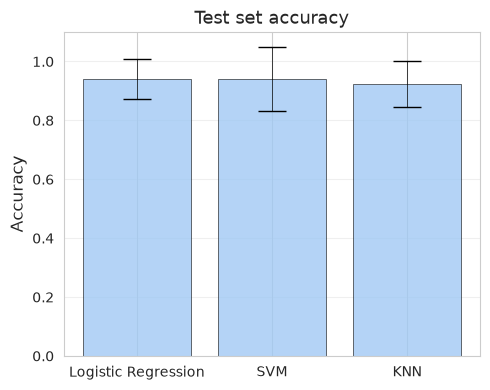

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))

models = [res['model_name'] for res in all_results]
accuracies = [res['accuracy_mean'] for res in all_results]
stds = [res['accuracy_std'] for res in all_results]
bars = ax.bar(models, accuracies, yerr=stds, capsize=10, alpha=0.8, edgecolor='black', linewidth=0.5, error_kw={'linewidth': 0.5})

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Test set accuracy", fontsize=13)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/09_nested_cv_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

### **4.2 AUC Comparison**

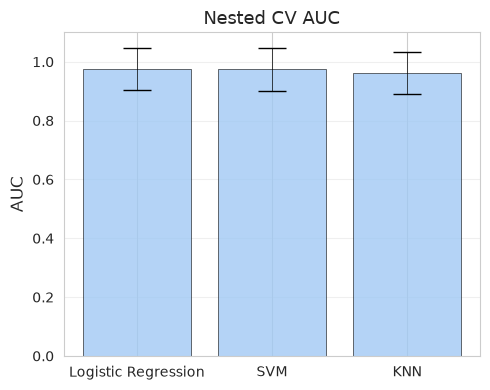

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))

aucs = [res['auc_mean'] for res in all_results]
auc_stds = [res['auc_std'] for res in all_results]

bars = ax.bar(models, aucs, yerr=auc_stds, capsize=10, alpha=0.8, edgecolor='black', linewidth=0.5, error_kw={'linewidth': 0.5})

ax.set_ylabel("AUC", fontsize=12)
ax.set_title("Nested CV AUC", fontsize=13)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/09_nested_cv_auc.png", dpi=300, bbox_inches='tight')
plt.show()

### **4.3 Fold-by-Fold Accuracy**

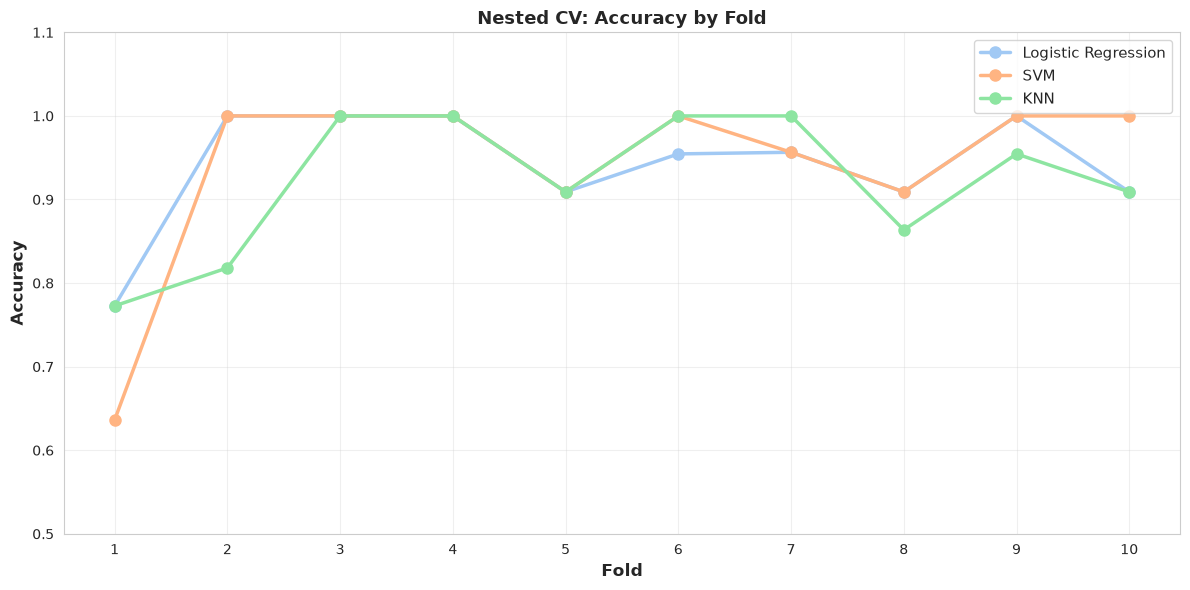

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

folds = np.arange(1, 11)
for i, res in enumerate(all_results):
    ax.plot(folds, res['accuracies'], 'o-', linewidth=2.5, markersize=8,
            label=res['model_name'])

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Nested CV: Accuracy by Fold', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim([0.5, 1.1])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/09_nested_cv_folds.png", dpi=300, bbox_inches='tight')
plt.show()

## **5. Conclusions**

In [22]:
# Rank models by accuracy
ranked = sorted(all_results, key=lambda x: x['accuracy_mean'], reverse=True)

print('\nModel Rankings by Accuracy:')
for i, res in enumerate(ranked, 1):
    print(f"{i}. {res['model_name']}: {res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}")


Model Rankings by Accuracy:
1. Logistic Regression: 0.941 ± 0.068
2. SVM: 0.941 ± 0.108
3. KNN: 0.923 ± 0.079
